# LBM Wind Tunnel — Right Triangle (Assignment 2)

In [1]:
import windTunnelLBM as wt
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

## Geometry check

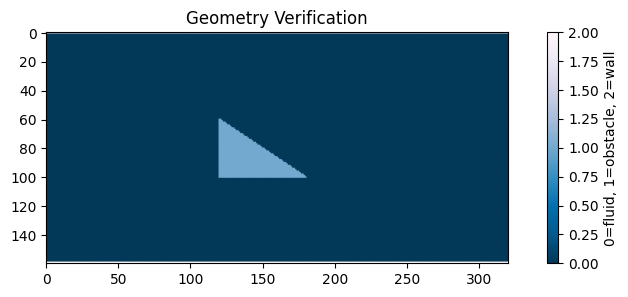

In [2]:
d_test = 40
test = wt.windTunnelLBM(15*d_test, 4*d_test, 1.9, d_test, 0.1)

plt.figure(figsize=(10, 3))
plt.imshow(test.getGeo(), cmap='PuBu_r')
plt.title('Geometry Verification')
plt.xlim(0, 8*d_test)
plt.colorbar(label='0=fluid, 1=obstacle, 2=wall')
plt.show()

## Simulation Run for Re = 10, 50, 100

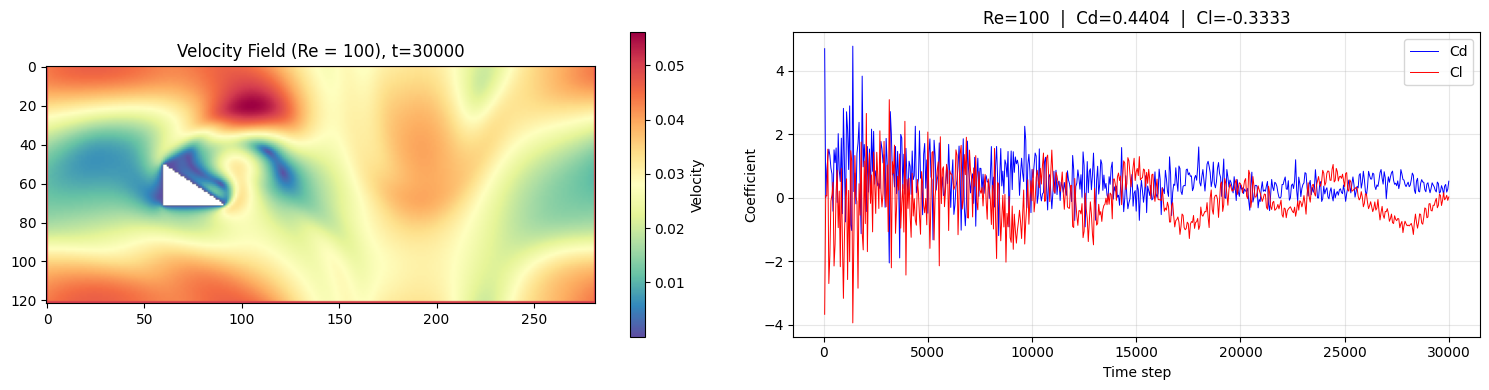

In [3]:
d = 20
uBC = 0.05
Re_list = [10, 50, 100]
num_steps = 30000
meas = 50  # measure every 50 steps
plot_every = 3000

all_cd = {}
all_cl = {}
all_lbm = {}

for Re in Re_list:
    nu = uBC * d / Re
    om = 1.0 / (3.0*nu + 0.5)
    cols = 14*d + 2
    rows = 6*d + 2
    print(f"Reynolds No: {Re} | d: {d} | uBC: {uBC} | nu: {nu:.4f} | omega: {om:.4f}")
    
    lbm = wt.windTunnelLBM(cols, rows, om, d, uBC)
    geo = lbm.getGeo()
    obs = (geo == 1)
    denom = 0.5 * uBC**2 * d
    
    cd_h, cl_h = [], []
    
    # computing Cd and Cl every 'meas' steps
    for step in range(meas, num_steps+1, meas):
        lbm.run(meas)
        cd_h.append(-lbm.getFx() / denom)    # cd = Fx / denom
        cl_h.append(-lbm.getFy() / denom)    # cl = Fy / denom
        
        if step % plot_every == 0:
            clear_output(wait=True)
            ux = lbm.getU()
            uy = lbm.getV()
            speed = np.sqrt(ux**2 + uy**2)
            speed[obs] = np.nan
            
            # velocity plot
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
            im = ax1.imshow(speed, cmap='Spectral_r')
            ax1.set_title(f'Velocity Field (Re = {Re}), t={step}')
            plt.colorbar(im, ax=ax1, label='Velocity')
            
            # Cd and Cl plot
            t_ax = np.arange(1, len(cd_h)+1) * meas
            ax2.plot(t_ax, cd_h, 'b', lw=0.7, label='Cd')
            ax2.plot(t_ax, cl_h, 'r', lw=0.7, label='Cl')
            ax2.legend() ; ax2.grid(True, alpha=0.3)
            ax2.set_xlabel('Time step') ; ax2.set_ylabel('Coefficient')
            n = min(len(cd_h), 100)         # average over last 100 measurements (stable region)
            ax2.set_title(f'Re={Re}  |  Cd={np.mean(cd_h[-n:]):.4f}  |  Cl={np.mean(cl_h[-n:]):.4f}')
            plt.tight_layout() ; plt.show() ; plt.close(fig)
    
    all_cd[Re] = cd_h   # history of Cd measured every 50 steps
    all_cl[Re] = cl_h   # history of Cl measured every 50 steps
    all_lbm[Re] = lbm   # store final LBM state for further analysis


## Computing Average Cd and Cl

In [4]:
print('Average Cd and Cl over last 100 measurements (stable region):')
print(f"{'Re':>5}  {'Cd':>10}  {'Cl':>10}")
print('-'*30)
for Re in Re_list:
    cd = np.mean(all_cd[Re][-100:])
    cl = np.mean(all_cl[Re][-100:])
    print(f"{Re:5d}  {cd:10.4f}  {cl:10.4f}")

Average Cd and Cl over last 100 measurements (stable region):
   Re          Cd          Cl
------------------------------
   10      0.3175      0.0386
   50      0.3178      0.0431
  100      0.4404     -0.3333


## Visualising Velocity fields at steady state (end timesetup)

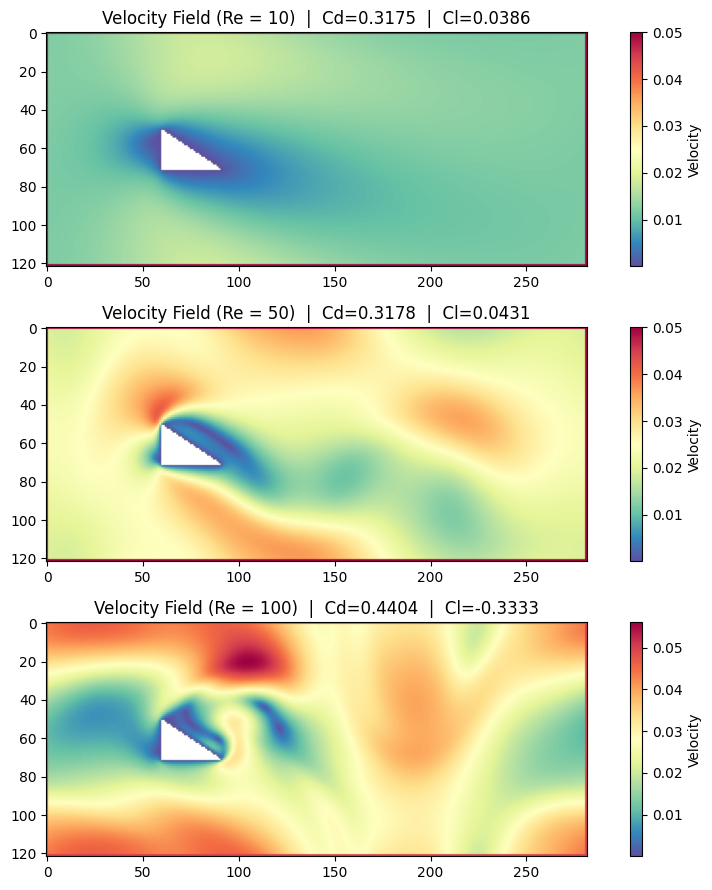

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9))

for i, Re in enumerate(Re_list):
    lbm = all_lbm[Re]
    ux = lbm.getU()
    uy = lbm.getV()
    geo = lbm.getGeo()
    speed = np.sqrt(ux**2 + uy**2)
    speed[geo==1] = np.nan
    
    im = axes[i].imshow(speed, cmap='Spectral_r')
    plt.colorbar(im, ax=axes[i], label='Velocity')
    cd = np.mean(all_cd[Re][-100:])
    cl = np.mean(all_cl[Re][-100:])
    axes[i].set_title(f'Velocity Field (Re = {Re})  |  Cd={cd:.4f}  |  Cl={cl:.4f}')

plt.tight_layout()
plt.savefig('velocity_fields.png', dpi=600)
plt.show()

## Evolution of $C_D$ and $C_L$ time histories

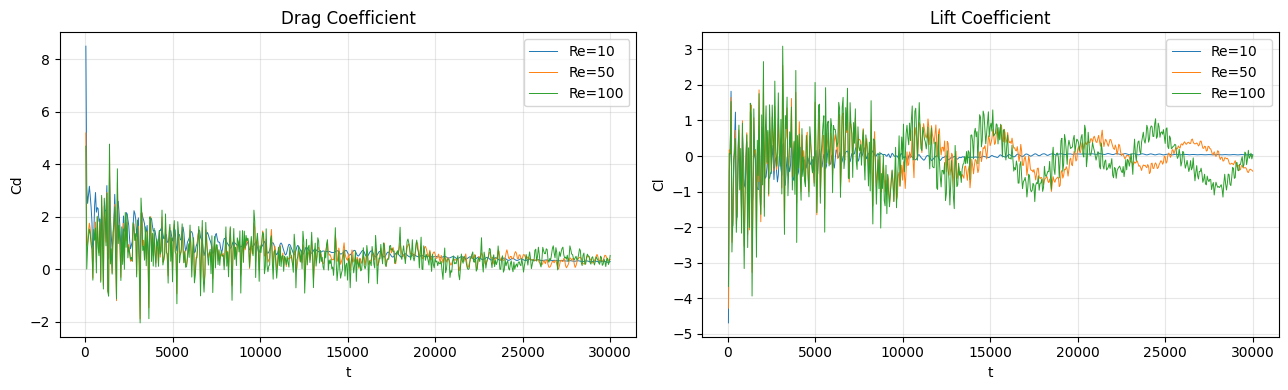

In [6]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for Re in Re_list:
    t = np.arange(1, len(all_cd[Re])+1) * meas
    ax1.plot(t, all_cd[Re], lw=0.7, label=f'Re={Re}')
    ax2.plot(t, all_cl[Re], lw=0.7, label=f'Re={Re}')

ax1.set_xlabel('t'); ax1.set_ylabel('Cd'); ax1.set_title('Drag Coefficient')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_xlabel('t'); ax2.set_ylabel('Cl'); ax2.set_title('Lift Coefficient')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Cd_Cl_history.png', dpi=600)
plt.show()

## Diffusive Scaling Convergence

Under diffusive scaling, when we refine the grid ($\Delta x \to \Delta x/2$, i.e. $d \to 2d$):
- Time step scales as $\Delta t \propto \Delta x^2$, so $\Delta t \to \Delta t/4$
- Lattice velocity $U_{LBM} = U_{phys} \cdot \Delta t / \Delta x \to U/2$
- Lattice viscosity $\nu_{LBM} = \nu_{phys} \cdot \Delta t / \Delta x^2$ stays constant → $\omega$ constant
- $Re = Ud/\nu$ stays constant ($U$ halves, $d$ doubles)
- Need $4\times$ more timesteps to reach same physical time

In [7]:
print("--- Convergence Under Diffusive Scaling (Re = 50) ---")

Re_conv = 50
d_list = [10, 20, 40]
U_base = 0.1
base_steps = 15000

conv_cd = []
conv_cl = []

for d in d_list:
    U = U_base * (d_list[0]/d)  # halve U  <==> doubling d
    nsteps = int(base_steps * (d/d_list[0])**2) # double d <==> 4x steps
    nu = U*d/Re_conv
    om = 1.0/(3.0*nu+0.5)
    cols = 14*d+2
    rows = 6*d+2
    
    print(f"d={d}, U={U:.4f}, omega={om:.4f}, steps={nsteps}")
    
    lbm = wt.windTunnelLBM(cols, rows, om, d, U)
    
    meas = max(100, nsteps//200)
    Cd_h = []
    Cl_h = []
    for step in range(meas, nsteps+1, meas):
        lbm.run(meas)
        Cd_h.append(-lbm.getFx() / (0.5*U**2*d))
        Cl_h.append(-lbm.getFy() / (0.5*U**2*d))
    
    n = max(1, len(Cd_h)//4)
    conv_cd.append(np.mean(Cd_h[-n:]))
    conv_cl.append(np.mean(Cl_h[-n:]))
    print(f"  Cd={conv_cd[-1]:.5f}, Cl={conv_cl[-1]:.5f}")


print("\n ==== Convergence table:====")
for i,d in enumerate(d_list):
    print(f"  d={d:3d}  Cd={conv_cd[i]:.5f}  Cl={conv_cl[i]:.5f}")

--- Convergence Under Diffusive Scaling (Re = 50) ---
d=10, U=0.1000, omega=1.7857, steps=15000
  Cd=0.13204, Cl=-0.01724
d=20, U=0.0500, omega=1.7857, steps=60000
  Cd=0.13928, Cl=-0.00293
d=40, U=0.0250, omega=1.7857, steps=240000
  Cd=0.14101, Cl=0.01030

 ==== Convergence table:====
  d= 10  Cd=0.13204  Cl=-0.01724
  d= 20  Cd=0.13928  Cl=-0.00293
  d= 40  Cd=0.14101  Cl=0.01030


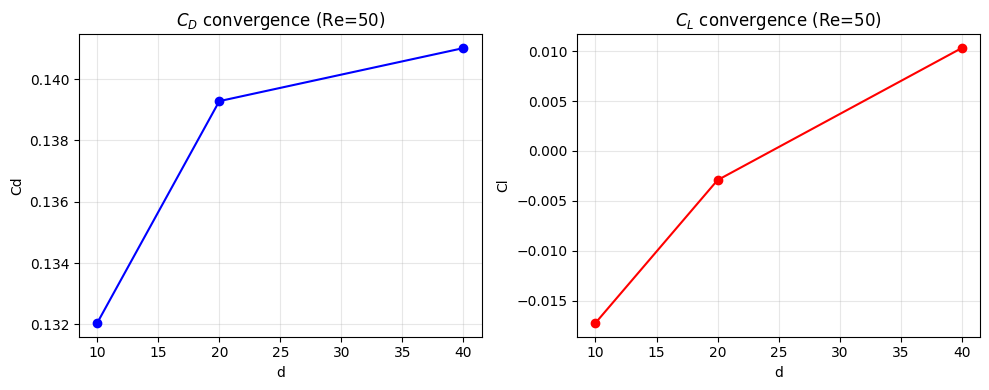

In [10]:
# Convergence plots of lift and drag coefficients under diffusive scaling

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(d_list, conv_cd, 'bo-')
ax1.set_xlabel('d') ; ax1.set_ylabel('Cd')
ax1.set_title(f'$C_D$ convergence (Re={Re_conv})'); ax1.grid(True, alpha=0.3)

ax2.plot(d_list, conv_cl, 'ro-')
ax2.set_xlabel('d') ; ax2.set_ylabel('Cl')
ax2.set_title(f'$C_L$ convergence (Re={Re_conv})'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence.png', dpi=600)
plt.show()

## Streamlines visualisation

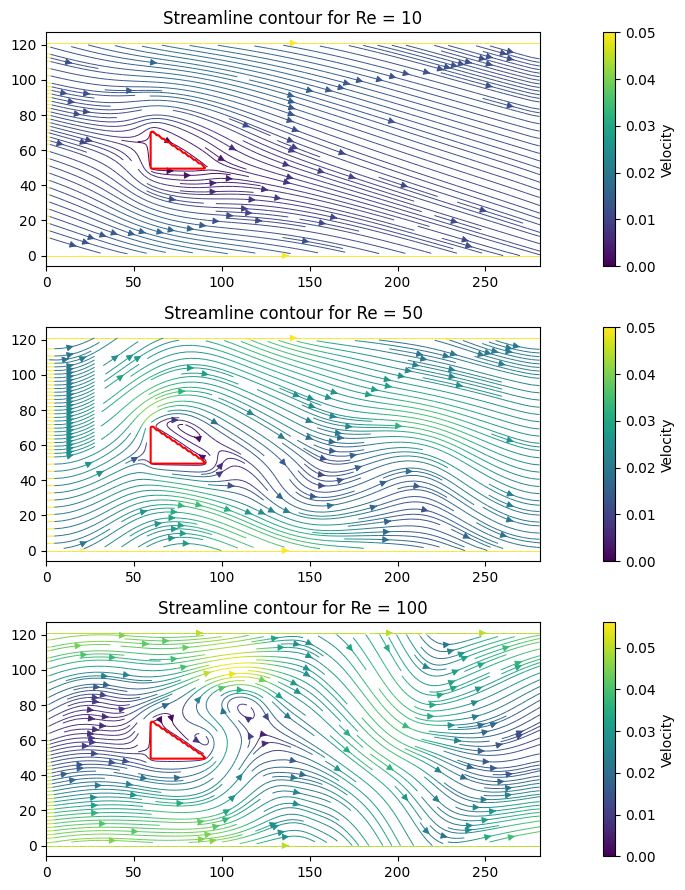

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9))

for i, Re in enumerate(Re_list):
    lbm = all_lbm[Re]
    ux = lbm.getU()
    uy = lbm.getV()
    geo = lbm.getGeo()
    nr, nc = ux.shape
    
    # Flip y-axis: imshow has y=0 at top, but streamplot uses Cartesian (y=0 at bottom)
    # So we flip all arrays vertically to match streamplot coords
    ux_f = np.flipud(ux.copy())
    uy_f = np.flipud(-uy.copy())  # also negate uy since y-axis is flipped
    geo_f = np.flipud(geo.copy())
    
    ux_f[geo_f==1] = 0
    uy_f[geo_f==1] = 0
    Y, X = np.mgrid[0:nr, 0:nc]
    speed = np.sqrt(ux_f**2 + uy_f**2)
    
    strm = axes[i].streamplot(X, Y, ux_f, uy_f, color=speed,
                       cmap='viridis', density=2, linewidth=0.7)
    plt.colorbar(strm.lines, ax=axes[i], label='Velocity')
    axes[i].contour(X, Y, (geo_f==1).astype(float), levels=[0.5], colors='red', linewidths=1.5)
    axes[i].set_title(f'Streamline contour for Re = {Re}')
    axes[i].set_aspect('equal')

plt.tight_layout()
plt.savefig('streamlines.png', dpi=600)
plt.show()